In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv")

print(df.shape)
display(df.head())
display(df.info())
display(df.describe().T)

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [3]:
print("Пропуски:")
print(df.isna().sum())

print("\nКоличество дубликатов:", df.duplicated().sum())

Пропуски:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Количество дубликатов: 240


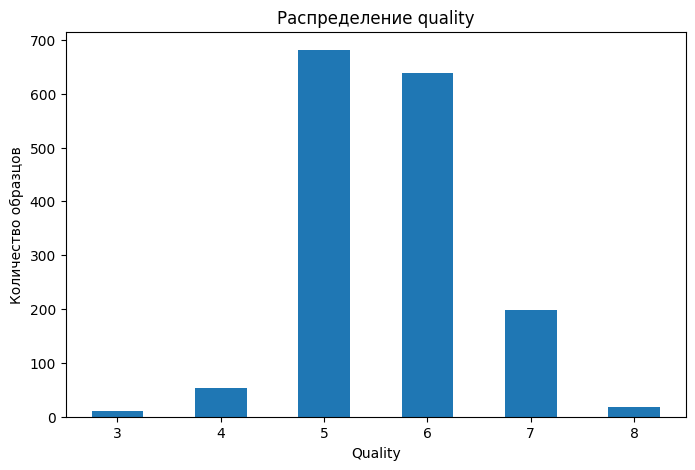

In [4]:
plt.figure(figsize=(8, 5))

df["quality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Quality")
plt.ylabel("Количество образцов")
plt.title("Распределение quality")
plt.xticks(rotation=0)
plt.show()

Дисбаланс заметен

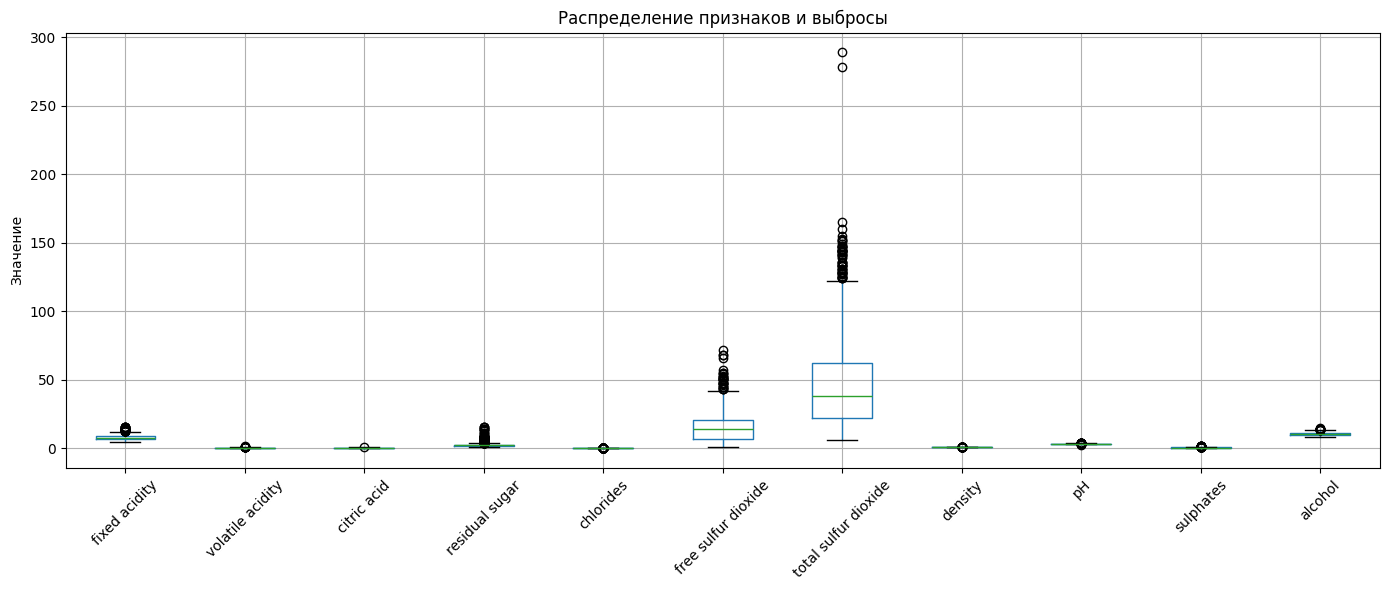

In [5]:
plt.figure(figsize=(14, 6))

df.drop(columns="quality").boxplot(rot=45)

plt.title("Распределение признаков и выбросы")
plt.ylabel("Значение")
plt.tight_layout()
plt.show()

С total sulfur dioxide явно что-то не так. Если бы я была экспертом в вине, я могла бы сказать, может он реально быть 250-300 или нет. Но я не эксперт, и от греха подальше потом просто выкину все выбросы. Но сначала попробую с ними.

Хотя нет, вероятно, что-то не так со всеми, просто значения total sulfur dioxide лучше соответствуют шкале графика. Попробую повторить график после скейлера.

In [6]:
X = df.drop(columns="quality")
y = df["quality"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (959, 11)
Validation: (320, 11)
Test: (320, 11)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

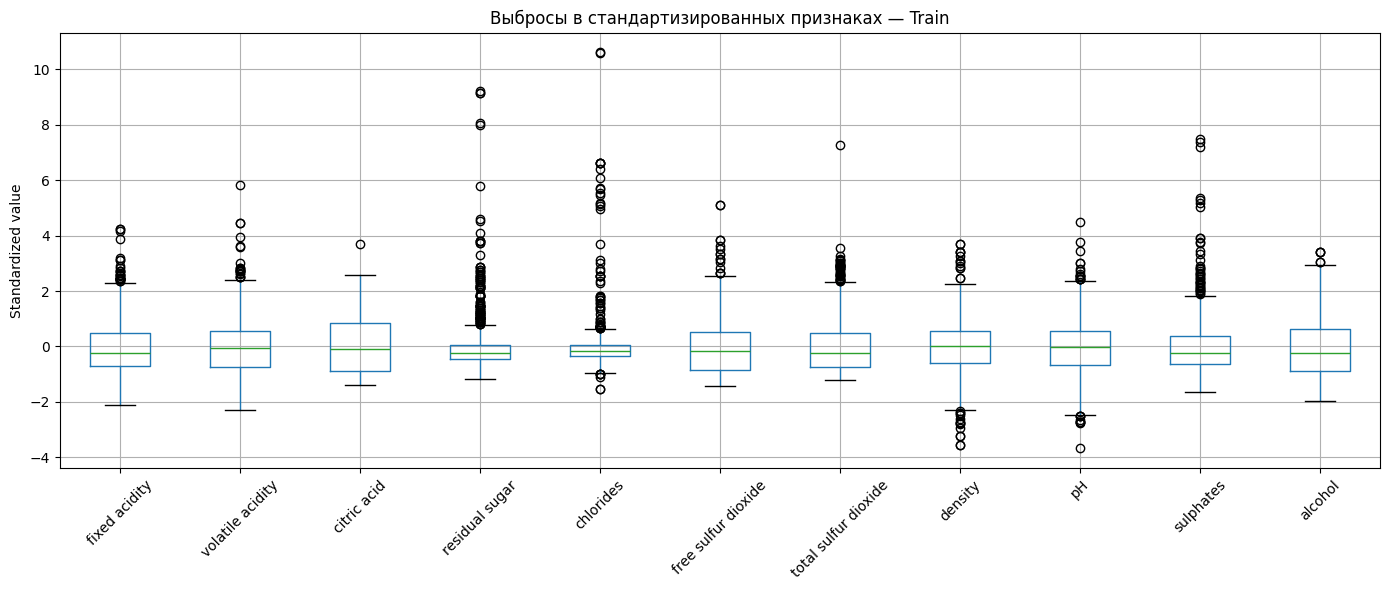

In [8]:
plt.figure(figsize=(14, 6))

pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).boxplot(rot=45)

plt.title("Выбросы в стандартизированных признаках — Train")
plt.ylabel("Standardized value")
plt.tight_layout()
plt.show()

In [9]:
def remove_outliers_iqr(X, y):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = ~((X < lower) | (X > upper)).any(axis=1)

    return X.loc[mask], y.loc[mask]

train_before = len(X_train)

X_train, y_train = remove_outliers_iqr(X_train, y_train)

train_after = len(X_train)

print("Train до удаления:", train_before)
print("Train после удаления:", train_after)
print("Удалено:", train_before - train_after)

Train до удаления: 959
Train после удаления: 693
Удалено: 266


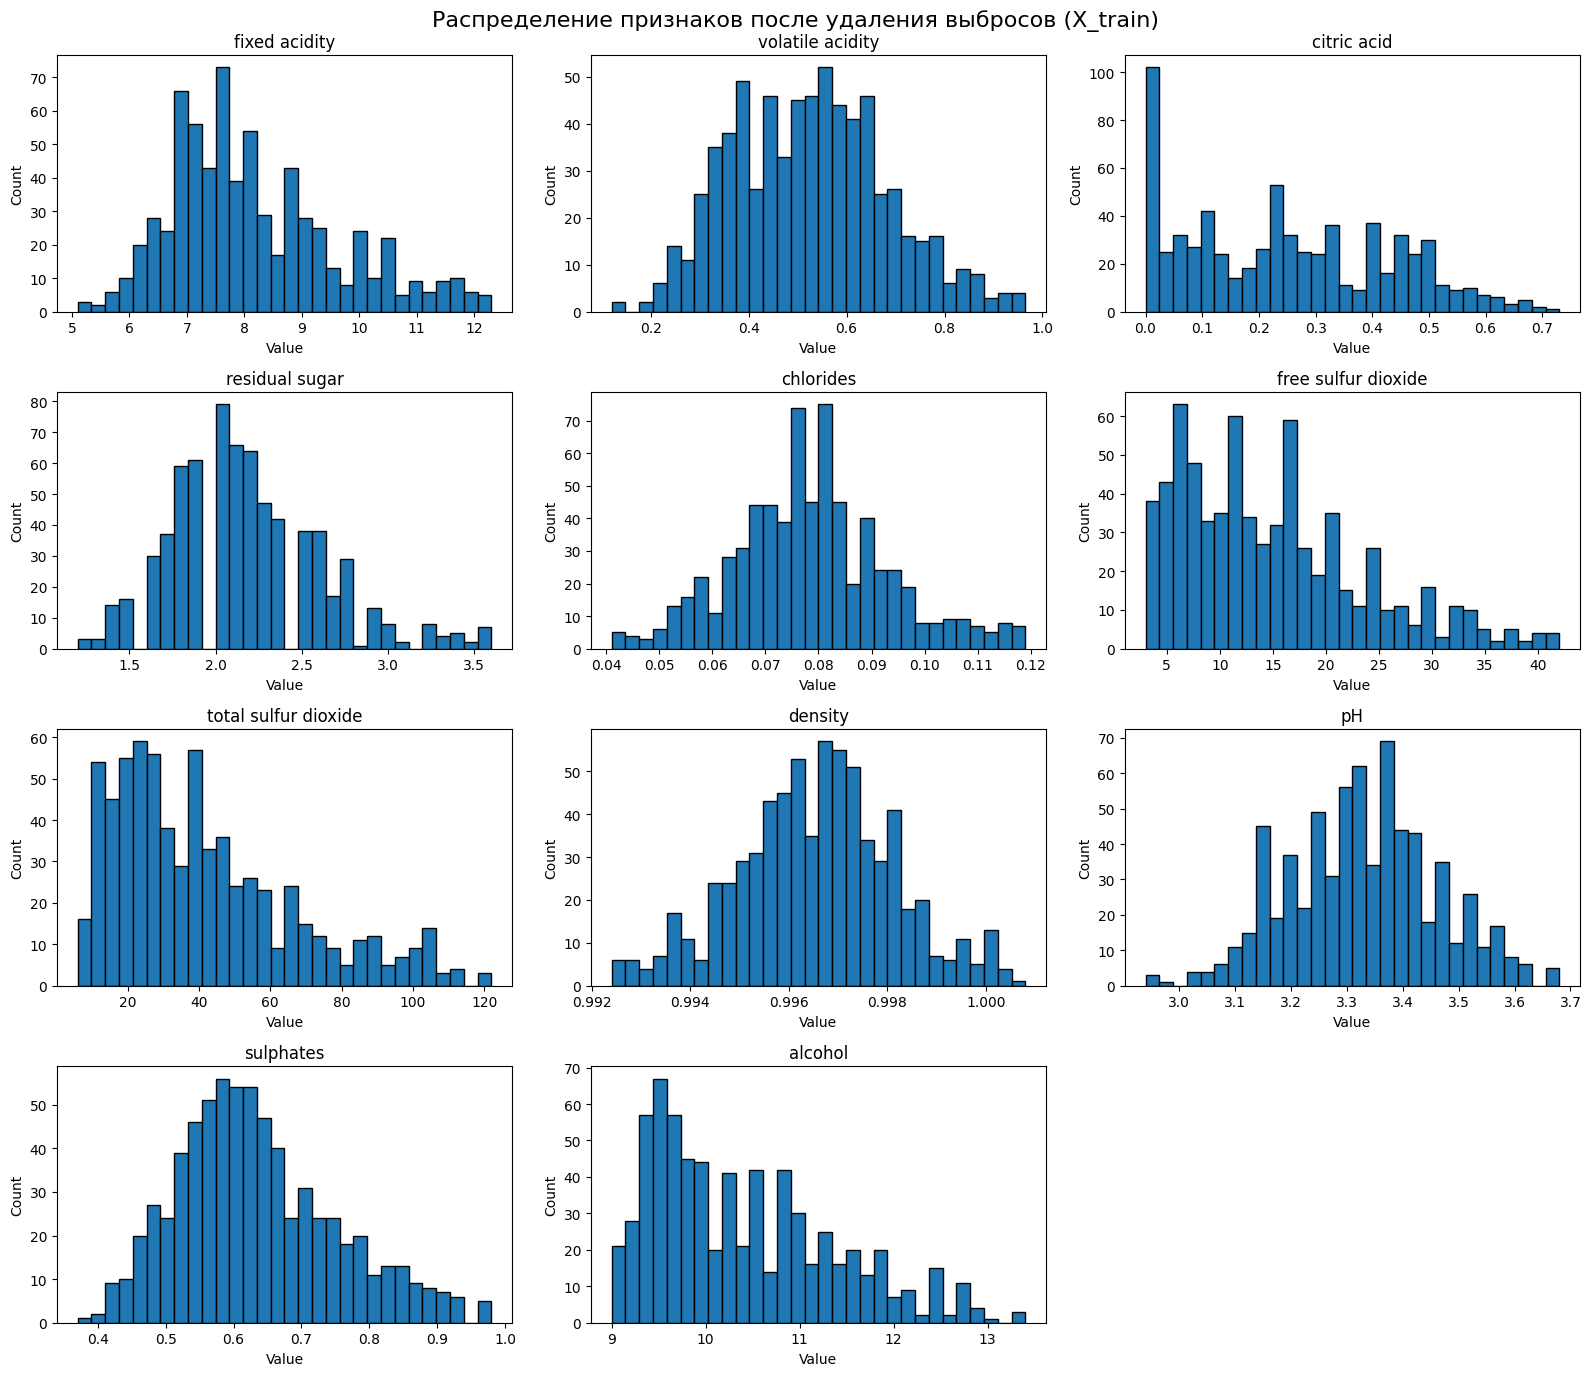

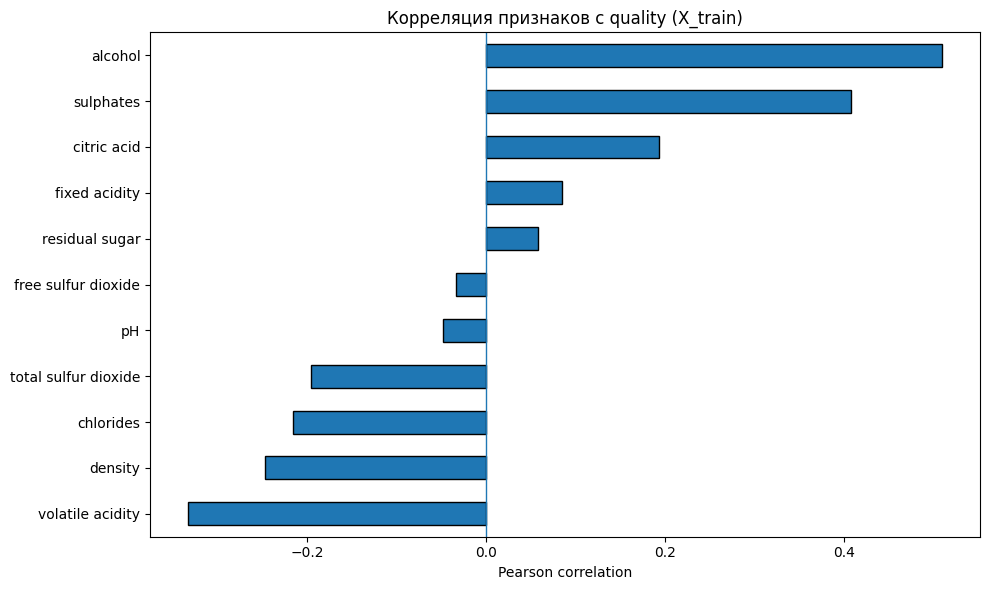

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

# Распределения признаков в очищенном X_train
for i, feature in enumerate(X_train.columns):
    axes[i].hist(X_train[feature], bins=30, edgecolor="black")
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

for ax in axes[len(X_train.columns):]:
    ax.remove()

plt.suptitle("Распределение признаков после удаления выбросов (X_train)", fontsize=16)
plt.tight_layout()
plt.show()


# Корреляция признаков с quality
train_corr = pd.concat([X_train, y_train], axis=1).corr()["quality"].drop("quality").sort_values()

plt.figure(figsize=(10, 6))
train_corr.plot(kind="barh", edgecolor="black")

plt.axvline(0, linewidth=1)
plt.xlabel("Pearson correlation")
plt.title("Корреляция признаков с quality (X_train)")
plt.tight_layout()
plt.show()

Скейлинг надо переделывать, данные изменились

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [12]:
linear = LinearRegression()

linear.fit(X_train_scaled, y_train)

y_train_pred = linear.predict(X_train_scaled)
y_val_pred = linear.predict(X_val_scaled)

In [13]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R²": r2_score(y_true, y_pred)
    }

In [14]:
baseline_results = pd.DataFrame({
    "Train": regression_metrics(y_train, y_train_pred),
    "Validation": regression_metrics(y_val, y_val_pred)
})

display(baseline_results.round(4))

,Train,Validation
MAE,0.4671,0.5059
RMSE,0.5905,0.6899
R²,0.3777,0.2501


Окей, это ужасно

In [15]:
linear_coef = pd.Series(
    linear.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

display(linear_coef.to_frame("Coefficient"))

,Coefficient
alcohol,0.244811
sulphates,0.195539
volatile acidity,-0.128017
density,-0.088823
fixed acidity,0.086232
citric acid,-0.060912
total sulfur dioxide,-0.043288
residual sugar,0.034835
pH,-0.028756
chlorides,-0.028539


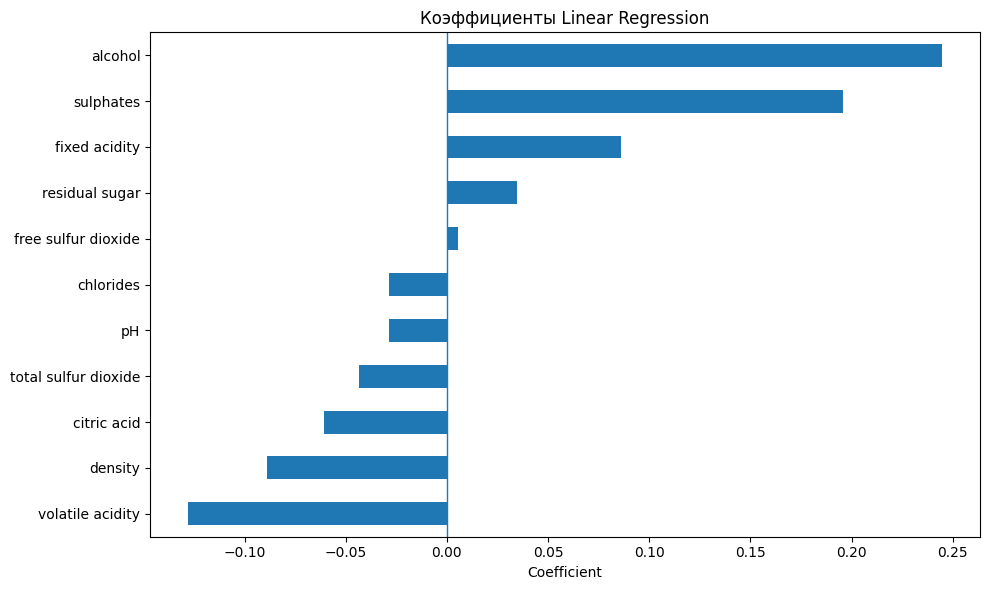

In [16]:
plt.figure(figsize=(10, 6))

linear_coef.sort_values().plot(kind="barh")

plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.title("Коэффициенты Linear Regression")
plt.tight_layout()
plt.show()

Где-то мы уже это видели.

Попробуем Ridge.

In [17]:
alphas = np.logspace(-3, 3, 13)

ridge_train = []
ridge_val = []
ridge_coefs = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    pred_train = model.predict(X_train_scaled)
    pred_val = model.predict(X_val_scaled)

    ridge_train.append(regression_metrics(y_train, pred_train))
    ridge_val.append(regression_metrics(y_val, pred_val))
    ridge_coefs.append(model.coef_)

ridge_train = pd.DataFrame(ridge_train, index=alphas)
ridge_val = pd.DataFrame(ridge_val, index=alphas)
ridge_coefs = np.array(ridge_coefs)

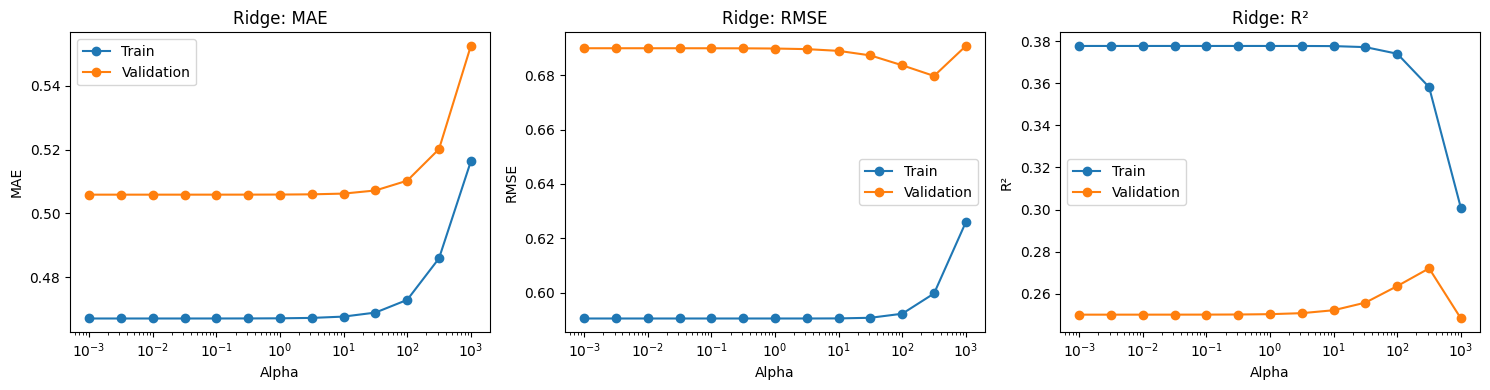

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    ax.plot(alphas, ridge_train[metric], marker="o", label="Train")
    ax.plot(alphas, ridge_val[metric], marker="o", label="Validation")
    ax.set_xscale("log")
    ax.set_xlabel("Alpha")
    ax.set_ylabel(metric)
    ax.set_title(f"Ridge: {metric}")
    ax.legend()

plt.tight_layout()
plt.show()

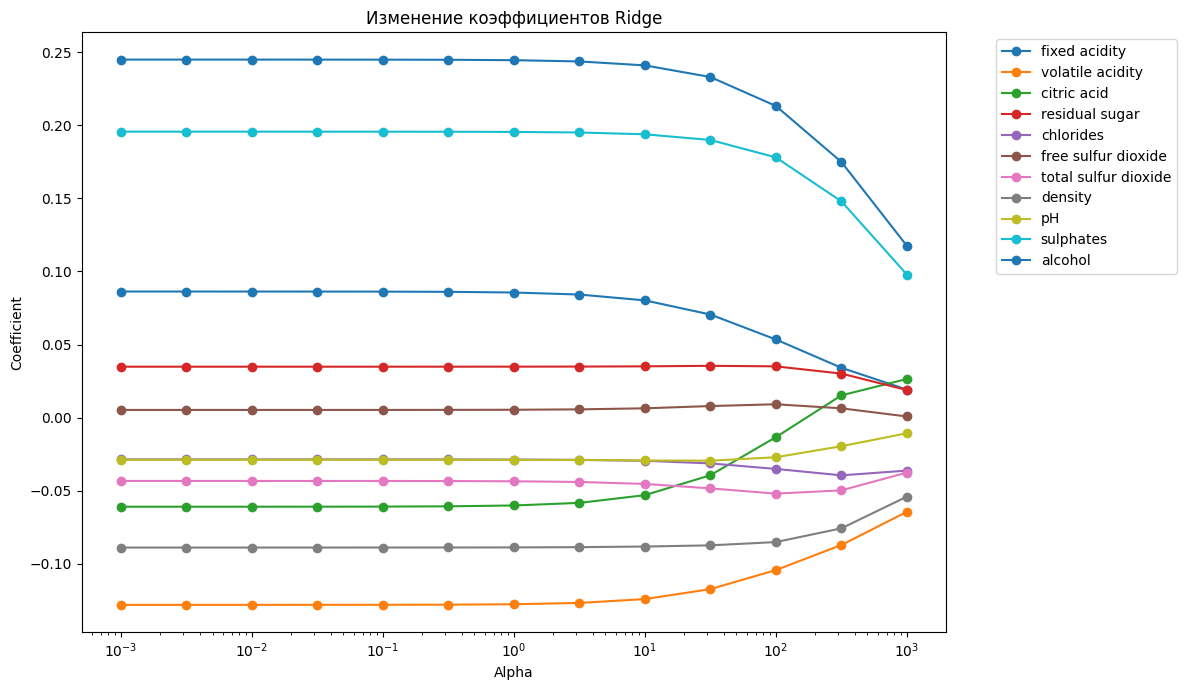

In [19]:
plt.figure(figsize=(12, 7))

for i, feature in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs[:, i], marker="o", label=feature)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Изменение коэффициентов Ridge")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Видно, что регуляризация очень слабо влияет на работу модели, возможно, потому, что модель работает ужасно. Только на очень больших значениях alpha регуляризация начинает ухудшать работу модели (логично: по мере увеличения альфа модель сильнее жертвует точностью ради уменьшения коэффициентов), но ухудшить такую плохую модель - задача со звездочкой, оно и понятно. 

При этом train и val ухудшаются одновременно. Переобучения нет. Регуляризация тут в целом не очень понятно зачем.

Посмотрим, как отработают другие варианты.

In [20]:
lasso_train = []
lasso_val = []
lasso_coefs = []
lasso_zero_counts = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)

    pred_train = model.predict(X_train_scaled)
    pred_val = model.predict(X_val_scaled)

    lasso_train.append(regression_metrics(y_train, pred_train))
    lasso_val.append(regression_metrics(y_val, pred_val))
    lasso_coefs.append(model.coef_)

    lasso_zero_counts.append(np.sum(model.coef_ == 0))

lasso_train = pd.DataFrame(lasso_train, index=alphas)
lasso_val = pd.DataFrame(lasso_val, index=alphas)
lasso_coefs = np.array(lasso_coefs)

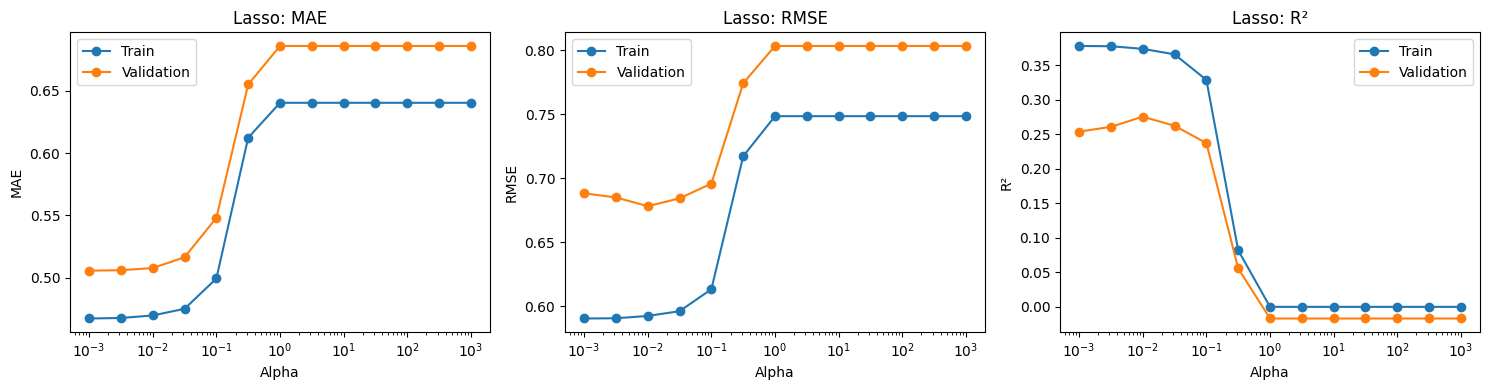

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    ax.plot(alphas, lasso_train[metric], marker="o", label="Train")
    ax.plot(alphas, lasso_val[metric], marker="o", label="Validation")
    ax.set_xscale("log")
    ax.set_xlabel("Alpha")
    ax.set_ylabel(metric)
    ax.set_title(f"Lasso: {metric}")
    ax.legend()

plt.tight_layout()
plt.show()

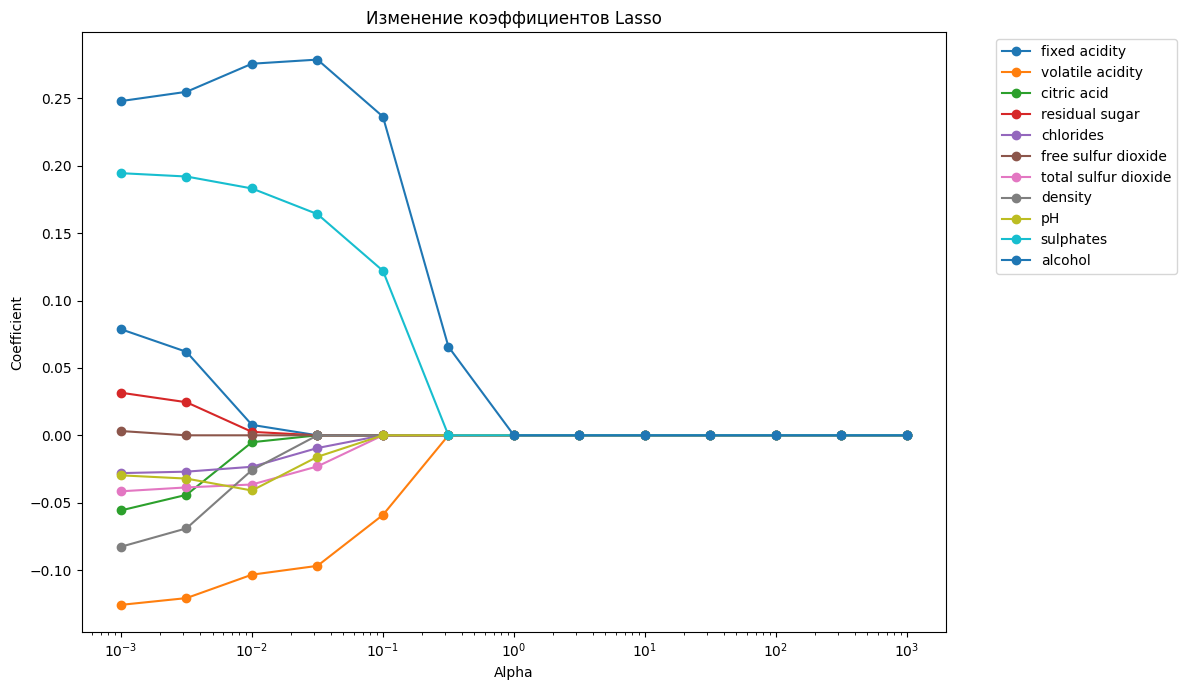

In [22]:
plt.figure(figsize=(12, 7))

for i, feature in enumerate(X.columns):
    plt.plot(alphas, lasso_coefs[:, i], marker="o", label=feature)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Изменение коэффициентов Lasso")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

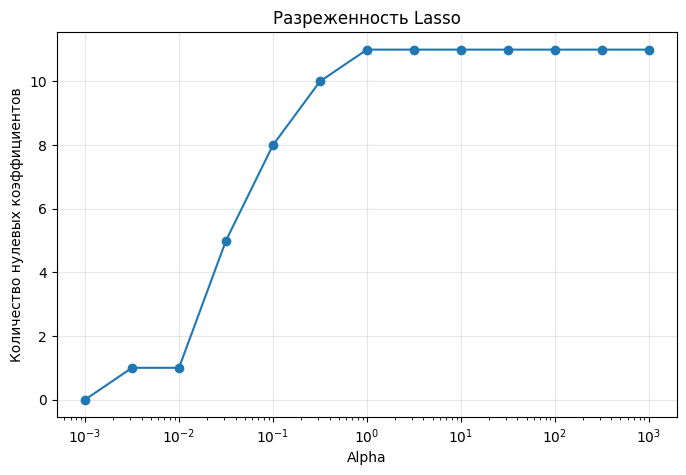

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(alphas, lasso_zero_counts, marker="o")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Количество нулевых коэффициентов")
plt.title("Разреженность Lasso")
plt.grid(True, alpha=0.3)
plt.show()

Занятно. Уже при alpha = 1, все признаки весят 0. Вероятно, потому, что качество вина определяется субъективно и зависит от настроения эксперта, бездушная машина здесь не поможет. Продолжаем наблюдения.

In [24]:
elastic_train = []
elastic_val = []
elastic_coefs = []

for alpha in alphas:
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    pred_train = model.predict(X_train_scaled)
    pred_val = model.predict(X_val_scaled)

    elastic_train.append(regression_metrics(y_train, pred_train))
    elastic_val.append(regression_metrics(y_val, pred_val))
    elastic_coefs.append(model.coef_)

elastic_train = pd.DataFrame(elastic_train, index=alphas)
elastic_val = pd.DataFrame(elastic_val, index=alphas)
elastic_coefs = np.array(elastic_coefs)

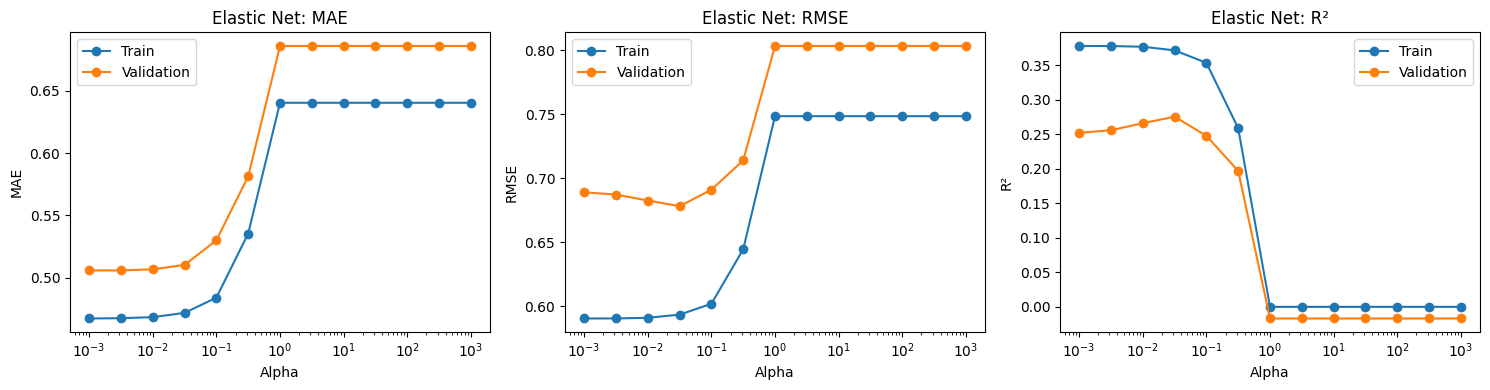

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    ax.plot(alphas, elastic_train[metric], marker="o", label="Train")
    ax.plot(alphas, elastic_val[metric], marker="o", label="Validation")
    ax.set_xscale("log")
    ax.set_xlabel("Alpha")
    ax.set_ylabel(metric)
    ax.set_title(f"Elastic Net: {metric}")
    ax.legend()

plt.tight_layout()
plt.show()

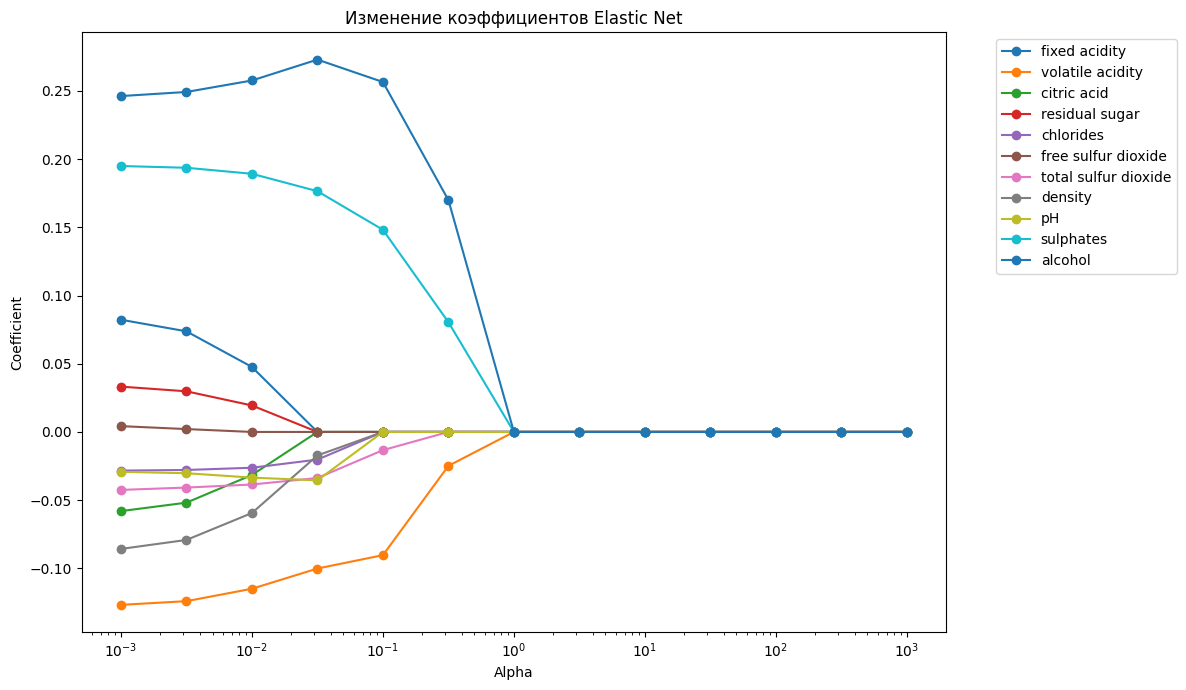

In [26]:
plt.figure(figsize=(12, 7))

for i, feature in enumerate(X.columns):
    plt.plot(alphas, elastic_coefs[:, i], marker="o", label=feature)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Изменение коэффициентов Elastic Net")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Та же картина, что и с Lasso. Сравнивать модели не вижу смысла: лучшая модель - без регуляризации. Сравним, чтобы увидеть то же самое, но кодом.

In [27]:
best_ridge_alpha = ridge_val["RMSE"].idxmin()
best_lasso_alpha = lasso_val["RMSE"].idxmin()
best_elastic_alpha = elastic_val["RMSE"].idxmin()

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Lasso alpha:", best_lasso_alpha)
print("Best Elastic Net alpha:", best_elastic_alpha)

Best Ridge alpha: 316.22776601683796
Best Lasso alpha: 0.01
Best Elastic Net alpha: 0.03162277660168379


Странный локальный минимум RMSE в Ridge, который не поддерживается ни MAE, ни R2, стал заметен.

В любом случае, в качестве лучшей регуляризации попробуем выбрать Lasso alpha = 0.01 (наименьшее значение). При этом лучше было бы, конечно, брать вообще исходную.

In [28]:
best_model = Lasso(
    alpha=best_lasso_alpha,
    max_iter=10000
)

best_model.fit(X_train_scaled, y_train)

Lasso(alpha=np.float64(0.01), max_iter=10000)

In [29]:
y_test_pred = best_model.predict(X_test_scaled)

test_results = regression_metrics(y_test, y_test_pred)

print("Финальная оценка на test:")

for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")

Финальная оценка на test:
MAE: 0.5096
RMSE: 0.6275
R²: 0.3975


In [30]:
linear_test_pred = linear.predict(X_test_scaled)

test_comparison = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test, linear_test_pred),
    "Selected Regularized Model": test_results
}).T

display(test_comparison.round(4))

,MAE,RMSE,R²
Linear Regression,0.5045,0.6226,0.4069
Selected Regularized Model,0.5096,0.6275,0.3975


Вывод: возможно, не стоит использовать регуляризацию, когда видно такое тяжелое недообучение.